# S07: ANOVA

The statistical procedure **Analysis of Variance** is actually an umbrella term used to classify a dozen or more different procedures. In this course, we will study 1-way ANOVA, the most plain vanilla version of ANOVA.

William Sealy Gosset created the $t$-test. While spetacularly successful, the $t$-test can be used at most with 2 samples. What if our statistical comparison involves 3 or more samples? Suppose we are comparing the *perfectionism* levels at a certain college among:
 
- Freshman
- Sophomores
- Juniors
- Seniors

The $t$-test by itself will not work, and performing the $\binom{4}{2} = 10$ $t$-tests needed to perform all the possible 2-way comparisons will drive the Type I error rate for the overall anaysis into the sky.

Ron Fisher took up the challenge and created the mathematical extension of the $t$-test for use with more than 2 groups. His statistical test is called **ANOVA** which stands for <span style = 'color:blue;font-weight:bold'>Analysis of Variance</span>.

Let's initialize the packages and functions we may need:

In [18]:
library('mosaic')

## Conducting the ANOVA in R
**Example.** Test whether the variable GPA varies based upon year in school (Yr).

We proceed through the following steps:
- Create the Model
   $$\text{mod = lm(GPA $\sim$ Yr, data = pers)}$$

- Extract the Residuals
   $$\text{res = residuals(mod)}$$

- Produce a QQ plot of the Residuals (as we did with linear regression)

- If the Data are Appropriate, Run the ANOVA
   $$\text{anova = aov(GPA $\sim$ Yr, data = pers)}$$

- <span style = 'color:blue;font-weight:bold'>Only if we reject the null, conduct a *post hoc* </span><span style = 'color:red;font-weight:bold'>Tukey HSD</span>
   $$\text{TukeyHSD(anova)}$$

## Getting Started

Let's load some data frames for our examples.

In [19]:
pers <- read.csv('https://faculty.ung.edu/rsinn/data/personality.csv')
city <- read.csv('https://faculty.ung.edu/rsinn/data/worldcity.csv')

## Example 1: Perfectionism

Test whether levels of perfectionism vary depending upon whether one prefers to sit in the front, middle, or back of the classroom using the **Perf** and **SitClass** columns of the personality data frame. Test at the $\alpha = 0.05$ level.

In [20]:
mod <- lm( Perf ~ SitClass , data = pers)
res = residuals(mod)

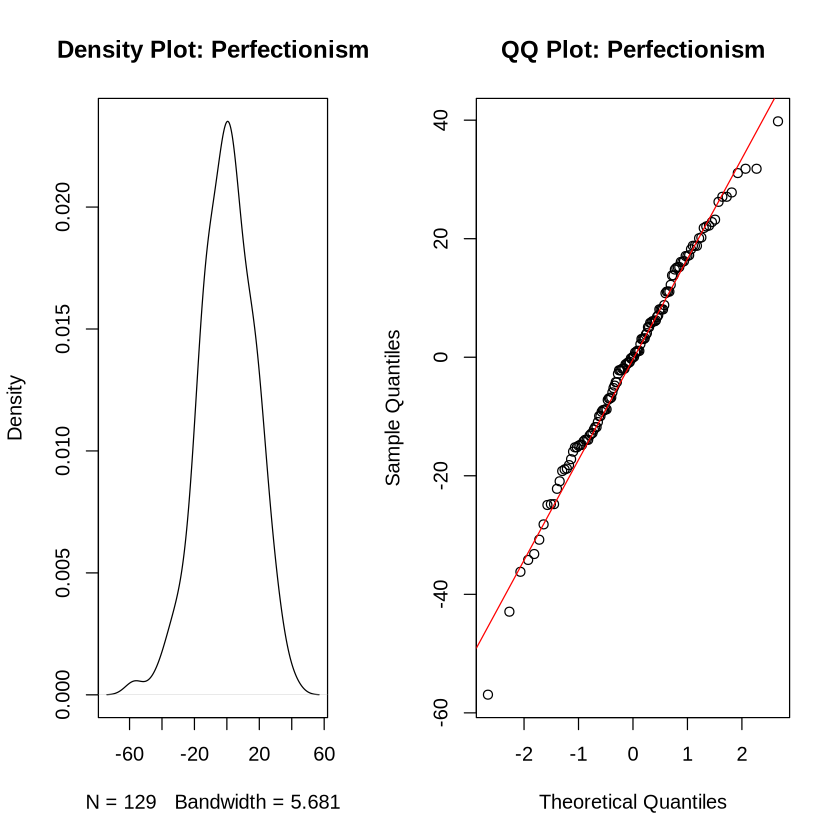

In [21]:
layout(matrix(c(1,2), ncol = 2), lcm(8))
plot(density(res), main = 'Density Plot: Perfectionism')
plot2 <- { qqnorm(mod$residual, main = 'QQ Plot: Perfectionism')
qqline(mod$residual, col = 'red') }

In [25]:
aggregate( Perf ~ SitClass , data = pers, length)

SitClass,Perf
<chr>,<int>
B,28
F,45
M,56


**Hypotheis:**

- $H_0 : \mu_f = \mu_m = \mu_b$
- At least 1 group mean is different.

** Data Checks**

We are checking that the residuals are approximately normally distributed which, from the QQ Plot, is clearly true.

The ratio of the larget to smallest group size is 2:1 which barely meets our requirements. Thus, we do not have a problem with different standard deviations for these groups, but the accuracy of our $p$-value may be eroded slightly.

In [27]:
anova <- aov( Perf ~ SitClass , data = pers)
summary(anova)

             Df Sum Sq Mean Sq F value Pr(>F)  
SitClass      2   2452  1225.8   4.334 0.0151 *
Residuals   126  35636   282.8                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Reporting Out**

Because $p = 0.0151 < 0.05 =\alpha$, we reject the null. We thus have evidence that at least one of these group means is different form the others.

We will now conduct a *post hoc* test: TukeyHSD.

In [18]:
TukeyHSD(anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Perf ~ SitClass, data = pers)

$SitClass
         diff         lwr        upr     p adj
F-B 10.414286   0.8136784 20.0148931 0.0300489
M-B  2.142857  -7.0890019 11.3747162 0.8464019
M-F -8.271429 -16.2565765 -0.2862806 0.0404878


We find an Honestly Significant Difference between:
- Front vs. Back (p = 0.03)
- Millde vs. Front (p = 0.04)

## Example 2: Optimism and Humor

Test whether <span style = 'color:blue'>optimism scores</span> vary based upon <span style = 'color:blue'>primary humor style</span> at the $\alpha = 0.05$ level. We will use the **CHS** and **PHS** variables in the personality data frame.

In [21]:
mod2 <- lm(Opt ~ PHS , data = pers)
res2 <- mod2$residual

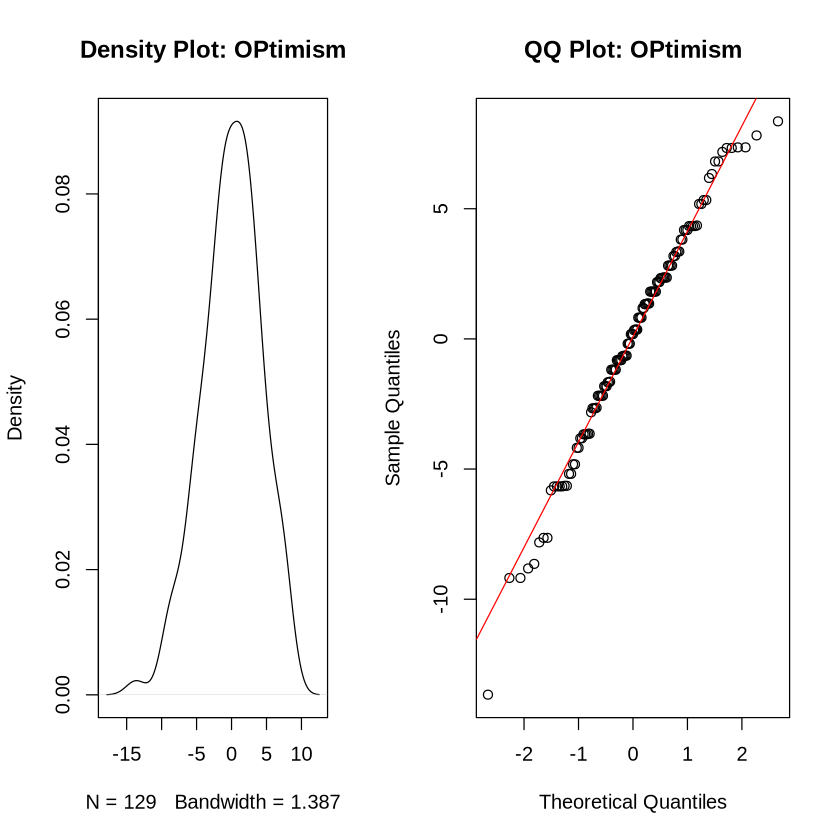

In [22]:
layout(matrix(c(1,2), ncol = 2), lcm(8))
plot(density(res2), main = 'Density Plot: OPtimism')
plot2 <- { qqnorm(mod2$residual, main = 'QQ Plot: OPtimism')
qqline(mod2$residual, col = 'red') }

**Hypothesis:**

- $H_0 : \mu_{af} = \mu_{ag} = \mu_{se} = \mu_{sd}$
- $H_a :$ At least 1 group mean is different.

**Data Checks**

The normality assumption is verified by the QQ plot being very linear.

The ratio of group sizes (largest to smallest) is less than 2:1.

In [25]:
anova2 <- aov(Opt ~ PHS , data = pers)
summary(anova2)

             Df Sum Sq Mean Sq F value  Pr(>F)   
PHS           3  267.8   89.26   4.942 0.00282 **
Residuals   125 2257.7   18.06                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Reporting Out**

Since $ p= 0.00282 < 0.05 = \alpha$, we reject the null. With evidence for a difference in group means, we will now conduct at Tukey HSD *post hoc* test.

In [26]:
TukeyHSD(anova2)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Opt ~ PHS, data = pers)

$PHS
           diff        lwr        upr     p adj
AG-AF -1.458647 -4.2148404 1.29754713 0.5154281
SD-AF -2.824675 -5.6680725 0.01872181 0.0522216
SE-AF  1.023810 -1.8841137 3.93173280 0.7959372
SD-AG -1.366029 -3.9992599 1.26720251 0.5325350
SE-AG  2.482456 -0.2203234 5.18523566 0.0839335
SE-SD  3.848485  1.0568329 6.64013677 0.0026402


The only group means that are significantly different are:

**<center><span style='color:maroon'>Self-enhancing vs. Self-defeating</span></center>**

## Example 3: Cities and Population

The **city** data frame lists the populations of the largest cities in the world. Test whether there is a difference in <span style = 'color:blue'>population averages</span> between China, India, Brazil and Japan at the $\alpha = 0.05$ level.

In [28]:
datatable <- subset(city, country == 'China' | country == 'India' | country == 'Brazil' | country == 'Japan', select = c(1,4,5))
head(datatable)

,city,country,population
,<chr>,<chr>,<dbl>
1,Tokyo,Japan,37977000
3,Delhi,India,29617000
4,Mumbai,India,23355000
6,Shanghai,China,22120000
7,Sao Paulo,Brazil,22046000
10,Guangzhou,China,20902000


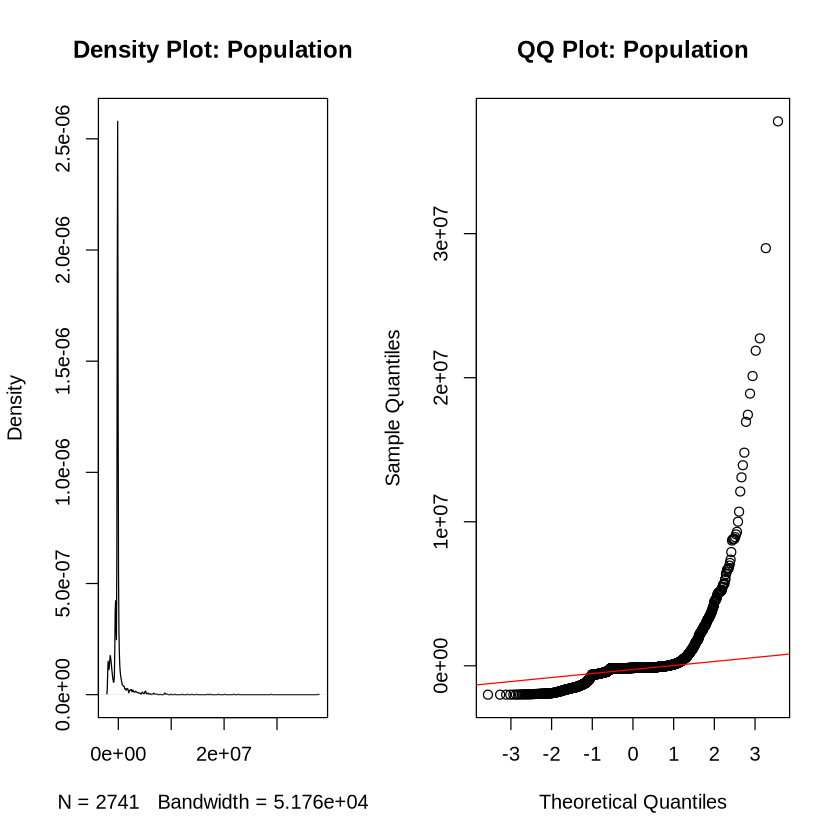

In [30]:
mod3 <- lm( population ~ country , data = datatable)
res3 <- mod3$residual
layout(matrix(c(1,2), ncol = 2), lcm(8))
plot(density(res3), main = 'Density Plot: Population')
plot2 <- { qqnorm(mod3$residual, main = 'QQ Plot: Population')
qqline(mod3$residual, col = 'red') }

**Data Checks**

The residuals for these data are **not** normally distributed, and thus these data are **not** appropriate for ANOVA.